# Term Project - CS329E

## Juhi Malwade

### Problem Definition & Overall Goal

In fast-paced environments like coffee shops, wait times play a major role in customer satisfaction. As a Starbucks customer, I've noticed a gap between expected and actual wait times. The mobile app provides an estimated pickup time, but these estimates are often unreliable. In-store orders offer no estimate at all, leaving customers to rely on their subjective judgement based on the store activity around them. 

The primary goal of this project is to build a multiple linear regression model (baseline) and a random forest regressor that estimates order fulfillment time at Starbucks. I aim to include relevant features such as time of day, day of the week, order type (mobile vs in-person), and number of customizations. Beyond prediction, I also want to determine which factors lead to certain wait times. Are certain times of day consistently associated with longer delays? Does mobile ordering actually reduce wait time? What is the impact of drink complexity on fulfillment speed? Answering these questions will help Starbucks optimize their staffing and improve customer transparency in terms of wait times.

### The Dataset

In my project, I will be analyzing a Starbucks Customer Ordering Patterns dataset. I acquired this dataset from [Kaggle](https://www.kaggle.com/datasets/likithagedipudi/starbucks-customer-ordering-patterns/data). It contains 100,000 transactions. These transactions have been simulated based on modern retail trends, as Starbucks does not release their actual transaction data to the public. 

The features in this dataset are:

- customer_id : unique identifier for the customer (captures repeat visits)

- order_id: unique transaction ID

- order_date: date of the transaction (Jan 2024 to Dec 2025)

- order_time: time of day
- day_of_week: day the order was placed
- order_channel : method used to place order (Mobile App, Drive-Thru, In-Store Cashier, or Kiosk)
- store_id: unique identifier for the store
- store_location_type : setting of the store (Urban, Suburban, Rural)
- region : geographic area (Northeast, Southeast, Midwest, West, or Southwest)
- customer_age_group : age range of the customer (18-24, 25-34, 35-44, 45-54, or 55+)
- customer_gender: gender identity of the customer
- is_rewards_member : indicates if the customer is part of the Starbucks Rewards program
- cart_size : total number of items in the order
- num_customizations : number of modifications made to the order (ex. extra shots, syrup, milk sub)
- total_spend : total cost of the transaction in USD
- fulfillment_time_min : total minutes from order placement to the customer receiving their items
- drink_category : type of drink ordered (Espresso, Brewed Coffee, Frappuccino, etc.)
- has_food_item : indicates if a food item was purchased
- order_ahead : indicates if mobile order was placed in advance
- customer_satisfaction : rating from 1 to 5

My outcome of interest is "fulfillment_time_min," since I hope to predict the total number of minutes it takes the customer to receive their items after placing an order. This is a regression task.

In [208]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("starbucks_customer_ordering_patterns.csv")
df

,customer_id,order_id,order_date,order_time,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction
0,CUST_12974,ORD_00000001,2024-03-25,08:47,Mon,Drive-Thru,STR_340,Suburban,Southwest,18-24,Male,False,5,0,14.48,8.2,Refresher,False,False,4
1,CUST_08235,ORD_00000002,2025-07-18,08:02,Fri,Mobile App,STR_425,Urban,Northeast,35-44,Female,True,1,3,9.52,5.4,Brewed Coffee,False,True,4
2,CUST_00393,ORD_00000003,2025-01-15,05:40,Wed,Kiosk,STR_103,Suburban,Midwest,25-34,Female,False,2,1,9.32,4.9,Brewed Coffee,False,False,5
3,CUST_06936,ORD_00000004,2024-07-30,15:10,Tue,Drive-Thru,STR_318,Suburban,Midwest,25-34,Female,True,2,1,9.55,3.5,Refresher,False,False,4
4,CUST_09800,ORD_00000005,2024-06-18,07:38,Tue,Drive-Thru,STR_338,Suburban,Northeast,35-44,Female,False,3,1,12.24,4.1,Frappuccino,False,False,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CUST_09857,ORD_00099996,2025-09-17,17:08,Wed,Mobile App,STR_016,Suburban,Northeast,45-54,Non-binary,True,4,0,15.18,3.2,Frappuccino,False,True,4
99996,CUST_09970,ORD_00099997,2024-08-03,08:07,Sat,Drive-Thru,STR_409,Rural,Southwest,35-44,Prefer not to say,True,5,2,16.71,5.5,Espresso,False,False,3
99997,CUST_04417,ORD_00099998,2025-01-11,16:05,Sat,In-Store Cashier,STR_191,Suburban,Northeast,55+,Female,False,3,0,9.12,3.3,Espresso,False,False,1
99998,CUST_07997,ORD_00099999,2025-10-23,18:32,Thu,Mobile App,STR_210,Rural,Southeast,18-24,Female,True,5,1,18.02,1.9,Other,False,False,2


### Data Cleaning and Pre-Processing

There are no null values that I need to account for. The dataset is already clean - this is likely because it is a simulated dataset.

In [209]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   customer_id            100000 non-null  object 
 1   order_id               100000 non-null  object 
 2   order_date             100000 non-null  object 
 3   order_time             100000 non-null  object 
 4   day_of_week            100000 non-null  object 
 5   order_channel          100000 non-null  object 
 6   store_id               100000 non-null  object 
 7   store_location_type    100000 non-null  object 
 8   region                 100000 non-null  object 
 9   customer_age_group     100000 non-null  object 
 10  customer_gender        100000 non-null  object 
 11  is_rewards_member      100000 non-null  bool   
 12  cart_size              100000 non-null  int64  
 13  num_customizations     100000 non-null  int64  
 14  total_spend            100000 non-nul

### Exploratory Data Analysis

There are 100,000 total orders with a mean cart size is 3.74 and total amount spent of $14.87. There don't seem to be any outliers in terms of fulfillment time - the minimum was 1 minute and the maximum was 11.2 minutes. The mean is 4.55 minutes. This seems reasonable. 

In [210]:
df.describe()

,cart_size,num_customizations,total_spend,fulfillment_time_min,customer_satisfaction
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,3.741510,1.81077,14.866771,4.546080,3.687530
std,1.697817,1.46280,5.506800,1.550269,1.184123
min,1.000000,0.00000,3.510000,1.000000,1.000000
25%,3.000000,1.00000,10.837500,3.400000,3.000000
50%,4.000000,2.00000,14.170000,4.400000,4.000000
75%,5.000000,3.00000,18.180000,5.500000,5.000000
max,10.000000,8.00000,40.310000,11.200000,5.000000


First, I plotted the histogram of fulfillment times. It was unimodal and fairly symmetric, which supports the fact that the median fulfillment time (4.4 minutes) is less than the mean fulfillment time (4.5 minutes). There did not seem to be any clear outliers.

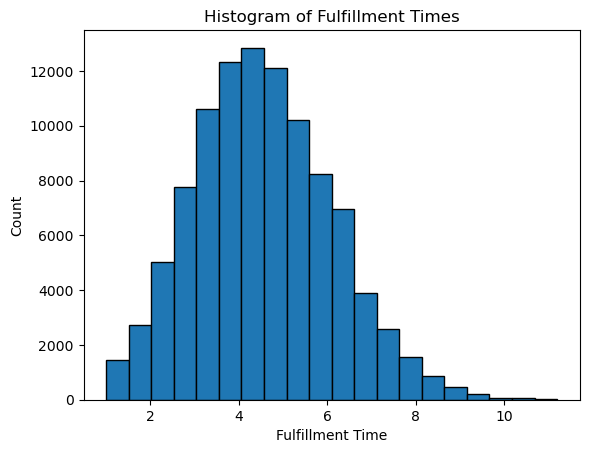

In [211]:
plt.hist(df['fulfillment_time_min'], 20, edgecolor = "black")
plt.title("Histogram of Fulfillment Times")
plt.xlabel("Fulfillment Time")
plt.ylabel("Count")
plt.show()

Next, I identified explanatory variables of interest and explored how they correlated to fulfillment times. These were based on my background knowledge of coffee shops/retail industry. These variables included:

- Store Location Type
- Day of Week
- Order Channel
- Total Spent
- Number Customizations
- Drink Category
- Has Food Item

There is potential multicollinearity between total spent and number customizations and drink category. However, I felt it was still important to total spent, as total spent is the only variable that accounts for the size of the drink. If I had included cart size instead of total spent, then a large latte with 5 shots of espresso would be viewed the same as small latte with 2 shots of espresso - both drinks take different amounts of time to make. Therefore, total spent explains more about wait times then cart size.

I did not include order time. In the dataset, order time ranged from 12:00am to 11:59pm, which did not seem realistic as most Starbucks are not open 24/7. With an actual Starbucks dataset, order time could definitely be a strong predictor of fulfillment time.

Lastly, I did not include order ahead. Only orders that were ordered through the mobile app can be considered "ordered ahead" so it is redundant to include both order channel and the boolean variable order ahead.

#### Univariate Analysis

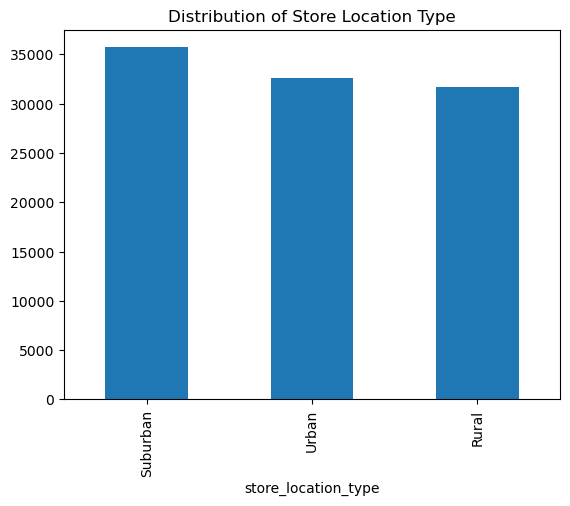

In [212]:
df['store_location_type'].value_counts().plot(kind = "bar")
plt.title("Distribution of Store Location Type")
plt.show()

Most of the locations in the dataset are suburban and the least are rural. However, there is a pretty even distribution between the three store types.

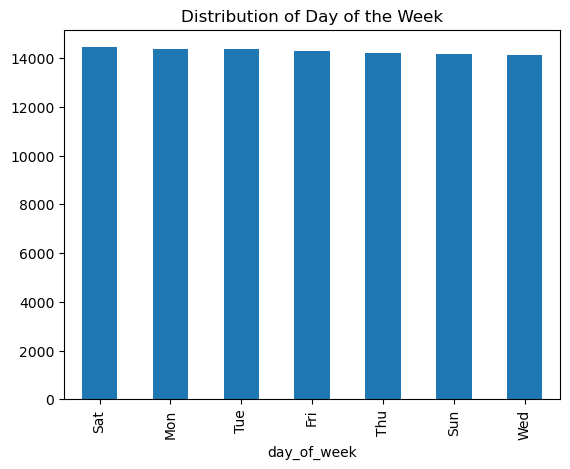

In [213]:
df['day_of_week'].value_counts().plot(kind = "bar")
plt.title("Distribution of Day of the Week")
plt.show()

There is a fairly even distribution between the 7 days of the week.

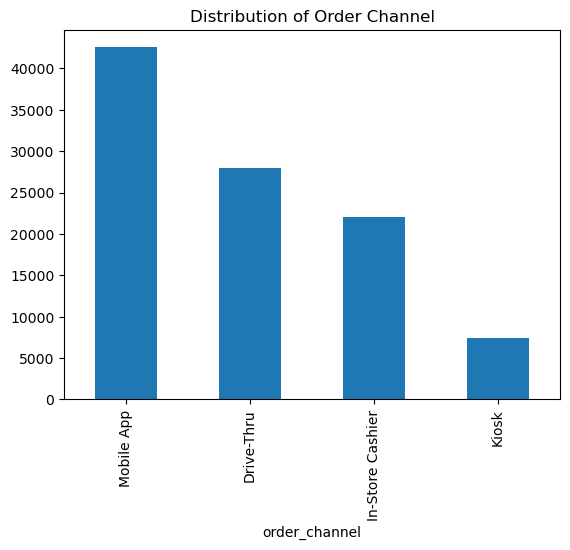

In [214]:
df['order_channel'].value_counts().plot(kind = "bar")
plt.title("Distribution of Order Channel")
plt.show()

Most of the orders were through a mobile app or drive-thru and the least were through kiosk. 

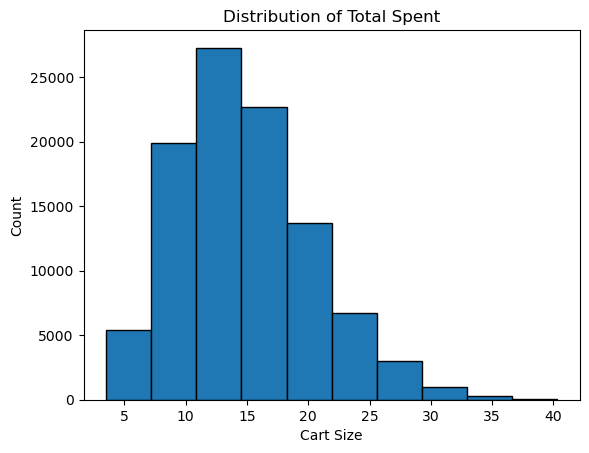

In [215]:
plt.hist(df['total_spend'], edgecolor = "black")
plt.title("Distribution of Total Spent")
plt.xlabel("Cart Size")
plt.ylabel("Count")
plt.show()

The distribution of cart size is right skewed with a mean of $14.87 and median of $14.17.

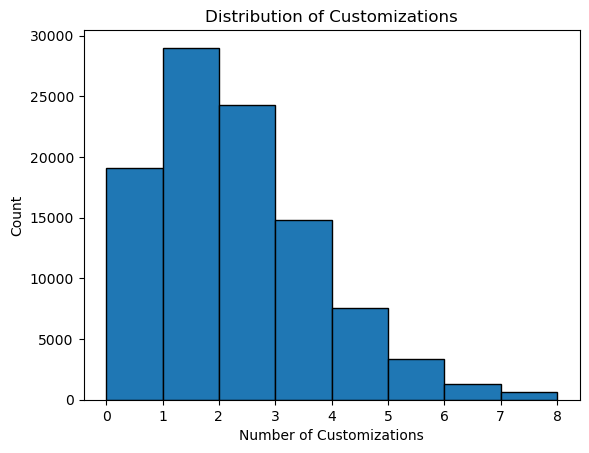

In [216]:
plt.hist(df['num_customizations'], 8, edgecolor = "black")
plt.title("Distribution of Customizations")
plt.xlabel("Number of Customizations")
plt.ylabel("Count")
plt.show()

There is a mean of 1.8 customizations and a median of 2 customizations per order. 

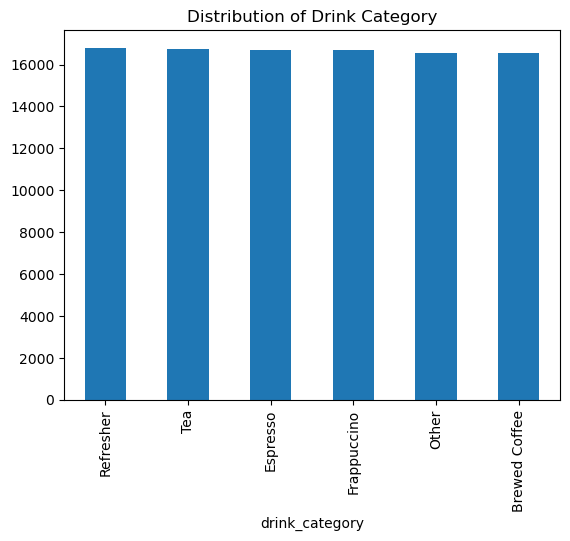

In [217]:
df['drink_category'].value_counts().plot(kind = "bar")
plt.title("Distribution of Drink Category")
plt.show()

The dataset has around the same number of drinks per category. 

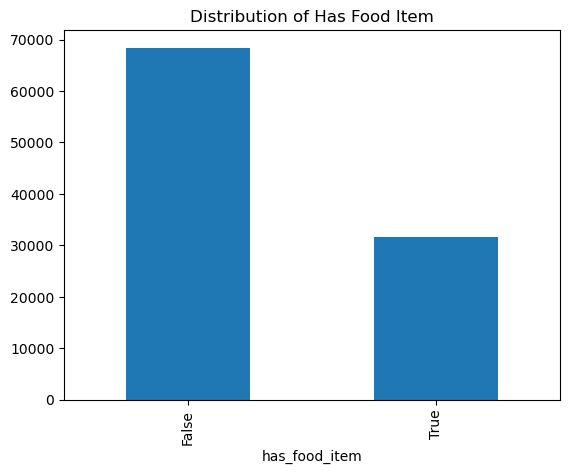

has_food_item
False    68419
True     31581
Name: count, dtype: int64

In [218]:
df['has_food_item'].value_counts().plot(kind = "bar")
plt.title("Distribution of Has Food Item")
plt.show()

df['has_food_item'].value_counts()

68,419 of the orders did not have a food item while 31,581 orders did.

#### Bivariate Analysis

Next, I plotted each of my 7 variables of interest against fulfillment time to determine which features actually impact fulfillment time.

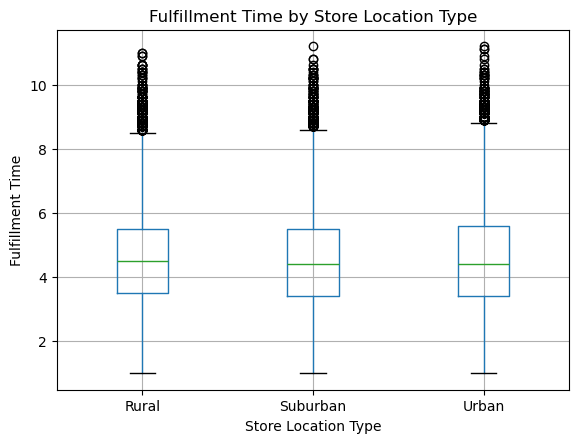

store_location_type
Rural       4.5
Suburban    4.4
Urban       4.4
Name: fulfillment_time_min, dtype: float64

In [219]:
df.boxplot(column="fulfillment_time_min", by="store_location_type")

plt.title("Fulfillment Time by Store Location Type")
plt.suptitle("")
plt.xlabel("Store Location Type")
plt.ylabel("Fulfillment Time")
plt.show()

df.groupby("store_location_type")['fulfillment_time_min'].median()

There is not a huge difference in fufillment time between the three store location types. While urban stores have a greater interquartile range, which makes sense since these stores tend to be more chaotic/unpredictable, it doesn't seem like store location alone drives fulfillment times. Rural locations have a slightly higher median than suburban and urban, but only by 0.1 minutes.

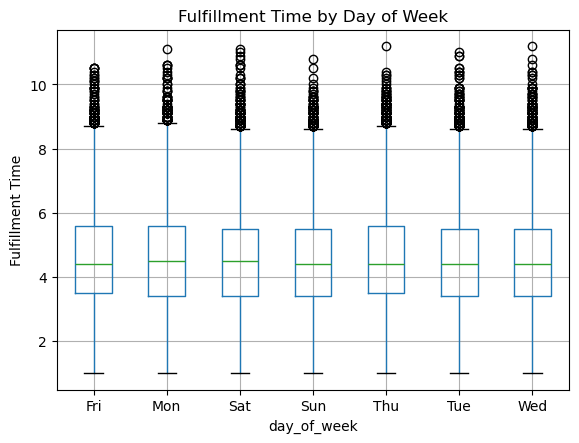

day_of_week
Fri    4.4
Mon    4.5
Sat    4.5
Sun    4.4
Thu    4.4
Tue    4.4
Wed    4.4
Name: fulfillment_time_min, dtype: float64

In [220]:
df.boxplot(column="fulfillment_time_min", by="day_of_week")

plt.title("Fulfillment Time by Day of Week")
plt.suptitle("")
plt.ylabel("Fulfillment Time")
plt.show()

df.groupby("day_of_week")['fulfillment_time_min'].median()

Again, there is not a huge difference between the days of the week. Mondays and Saturdays have slightly higher median fulfillment times, but it is only a 0.1 minute difference.

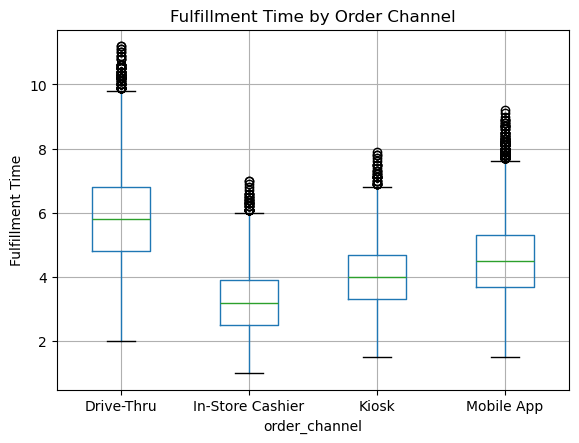

order_channel
Drive-Thru          5.8
In-Store Cashier    3.2
Kiosk               4.0
Mobile App          4.5
Name: fulfillment_time_min, dtype: float64

In [221]:
df.boxplot(column="fulfillment_time_min", by="order_channel")

plt.title("Fulfillment Time by Order Channel")
plt.suptitle("")
plt.ylabel("Fulfillment Time")
plt.show()

df.groupby("order_channel")['fulfillment_time_min'].median()

Now there's a pretty big difference - order channel seems to have an impact on fulfillment time. Drive-thru orders had the longest median fulfillment times of 5.8 minutes, while in-store had the shortest of 3.2 minutes. This makes sense, as drive-thru vehicles add to the amount of time it takes a customer to get to the window. Drive through also had the biggest range.

[]

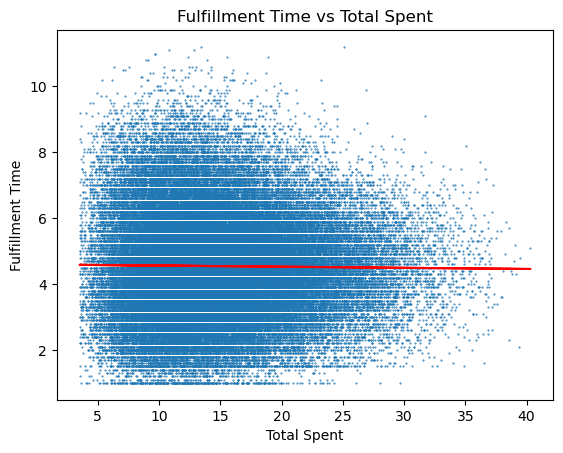

In [222]:
x = df['total_spend']
y = df['fulfillment_time_min']

plt.scatter(x, y, s = 0.2)
m, b = np.polyfit(x, y, 1)

plt.plot(x, m*x + b, color = "red")
plt.xlabel("Total Spent")
plt.ylabel("Fulfillment Time")
plt.title("Fulfillment Time vs Total Spent")

plt.plot()

Surprisingly, the total amount spent does not seem to have a correlation with fulfillment time. In fact, fulfillment time very slightly decreases as total spent increases.

[]

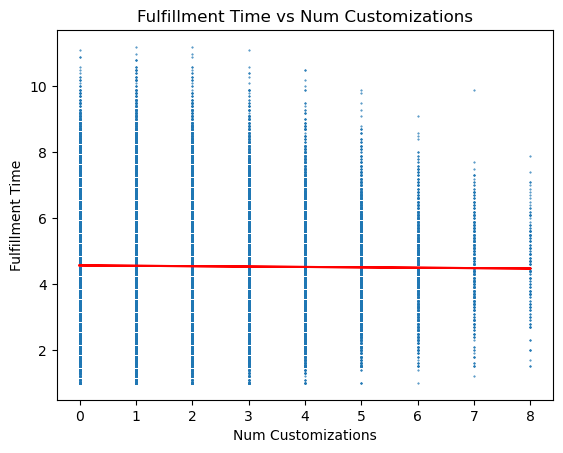

In [223]:
x = df['num_customizations']
y = df['fulfillment_time_min']

plt.scatter(x, y, s = 0.2)
m, b = np.polyfit(x, y, 1)

plt.plot(x, m*x + b, color = "red")
plt.xlabel("Num Customizations")
plt.ylabel("Fulfillment Time")
plt.title("Fulfillment Time vs Num Customizations")

plt.plot()

There seems to be no correlation between number of customizations and fulfillment time. In fact, fulfillment time slightly decreases as number of customizations increase (perhaps Starbucks workers prioritize orders with many modifications since they believe they will take longer).

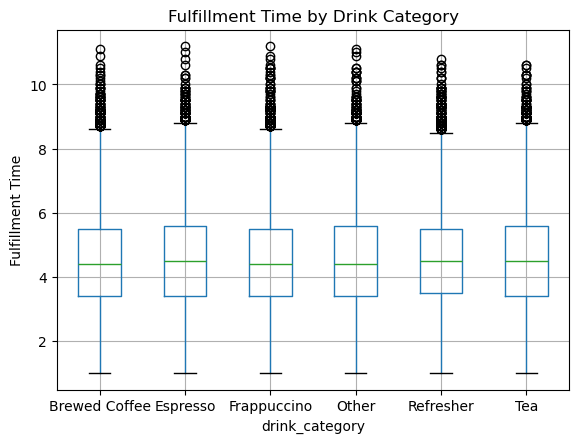

drink_category
Brewed Coffee    4.4
Espresso         4.5
Frappuccino      4.4
Other            4.4
Refresher        4.5
Tea              4.5
Name: fulfillment_time_min, dtype: float64

In [224]:
df.boxplot(column="fulfillment_time_min", by="drink_category")

plt.title("Fulfillment Time by Drink Category")
plt.suptitle("")
plt.ylabel("Fulfillment Time")
plt.show()

df.groupby("drink_category")['fulfillment_time_min'].median()

There is not a huge difference in median wait times between categories. Brewed coffee and frappuccinos have slightly lower fulfillment times than the other drink types.

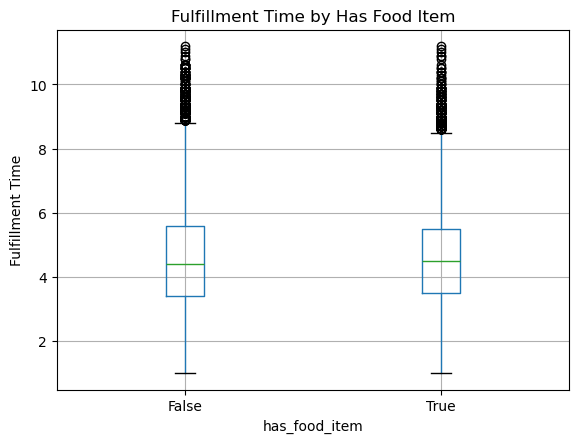

has_food_item
False    4.4
True     4.5
Name: fulfillment_time_min, dtype: float64

In [225]:
df.boxplot(column="fulfillment_time_min", by="has_food_item")

plt.title("Fulfillment Time by Has Food Item")
plt.suptitle("")
plt.ylabel("Fulfillment Time")
plt.show()

df.groupby("has_food_item")['fulfillment_time_min'].median()

Carts with food items take slightly longer than those without, but there is only a 0.1 minute difference in medians.

### Baseline Model: Multiple Linear Regression

Now that I have a good feel for the dataset, I will start by creating a baseline linear regression model.

First, I defined the features and the target variable. Based on the results above and tweaking of the models below, I ended up only keeping the features: store_location_type, order_channel, num_customizations, and has_food_item. 

In [226]:
X = df[['store_location_type', 'order_channel', 'num_customizations', 'has_food_item']]
y = df["fulfillment_time_min"]

Next, I split the columns into categorical and numeric, so that the categorical variables could be encoded.

In [227]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

#Convert boolean var to numeric
X["has_food_item"] = X["has_food_item"].astype(int)
numeric_cols += ["has_food_item"]

/var/folders/mp/_rmm88r93jxc59v77n11cnn00000gn/T/ipykernel_8277/3898036580.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["has_food_item"] = X["has_food_item"].astype(int)


I used one hot encoding to preprocess the data.

In [228]:
#One hot encoding
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

I then used a 80-20 train-test split.

In [229]:
#Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Then, I fit the linear regression model. It had an R^2 value of 0.359, which is fairly low. The baseline multiple linear regression model is not the best. 

In [230]:
from sklearn.linear_model import LinearRegression

lin_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lin_pipeline.fit(X_train, y_train)

y_pred_lin = lin_pipeline.predict(X_test)

print("R^2:", r2_score(y_test, y_pred_lin))

R^2: 0.35871519309137334


Even though the results weren't great, I still was curious to see how each feature contributed to fulfillment times. The coefficients show that drive thru and mobile app ordering contributed the most to higher fulfillment times and in store and kiosk contributed the most to lower fulfillment times. This goes to show that order channel has the most feature importance when it comes to predicting fulfillment times for this model. 

In [231]:
feature_names = (
    lin_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = lin_pipeline.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
}).sort_values(by="coefficient", ascending=False)

print(coef_df.head(5)) 
print(coef_df.tail(5))

                          feature  coefficient
3   cat__order_channel_Drive-Thru     1.424129
6   cat__order_channel_Mobile App     0.126692
8              num__has_food_item     0.016697
2  cat__store_location_type_Urban     0.009010
0  cat__store_location_type_Rural     0.005961
                               feature  coefficient
0       cat__store_location_type_Rural     0.005961
7              num__num_customizations    -0.003278
1    cat__store_location_type_Suburban    -0.014971
5             cat__order_channel_Kiosk    -0.374907
4  cat__order_channel_In-Store Cashier    -1.175914


### Random Forest Regressor

I expected the random forest regressor to have better results, as it uses an ensemble of trees to make predictions. It typically performs better on complex, non-linear relationships and gives interpretable feature importance scores.

However, the R^2 value was again 0.358, which is approximately the same as the Multiple Linear Regression model.

In [232]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

print("\nRandom Forest:")
print("R^2:", r2_score(y_test, y_pred_rf))


Random Forest:
R^2: 0.357905660802026


The feature importance scores show that drive thru, in store cashier, and mobile app contributed most to the predictions. Again, this goes to show that order method is the main predictor of fufillment time for this model.

In [238]:
feature_names = (
    rf_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = rf_pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(importance_df.head(15))

                               feature  importance
3        cat__order_channel_Drive-Thru    0.710744
4  cat__order_channel_In-Store Cashier    0.264201
6        cat__order_channel_Mobile App    0.014503
7              num__num_customizations    0.003628
5             cat__order_channel_Kiosk    0.003536
8                   num__has_food_item    0.001350
1    cat__store_location_type_Suburban    0.000756
0       cat__store_location_type_Rural    0.000645
2       cat__store_location_type_Urban    0.000638


### Reflection and Takeaways

The multiple linear regression and random forest models were not very predictive of fulfillment times. However, these models did reveal the how much of an impact order type channel has on wait times - ordering through the app typically results in shorter wait times while drive thru orders are longer.

A major limitation of this project is the fact that the data itself is simulated and may not be representative of true Starbucks data. This includes the fact that order time ranged from all 24 hours, which is not realistic. If I had realistic order time data, this likely would have contributed to a better model since I could account for how morning and afternoon peaks contribute to fulfillment times.

To hopefully improve my results, I plan to filter the dataset to only include orders made during store hours. Then, since the data is temporal, I will apply cyclical encoding (sine/cosine) to the times to represent their periodic nature. 

Additionally, the dataset lacked  key variables that could have significantly improved model performance. For instance, information on the number of employees or store capacity would likely have strong predictive power.

Overall, while the results weren't what I hoped, there is still promise in Starbucks pursuing this project with their own internal datasets to develop more accurate wait time predictions.

### References

The dataset was acquired from [Kaggle](https://www.kaggle.com/datasets/likithagedipudi/starbucks-customer-ordering-patterns/data).

